In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def as_bool(x):
    if isinstance(x, str):
        return x.lower() == "true"
    return bool(x)


def yperiodic_string(x):
    return "true" if as_bool(x) else "false"


def results_geometry_folder(plot_type):
    """
    Zamienia nazwę geometrii używaną w funkcjach rysujących
    na nazwę katalogu w results/.

    Przykłady:
        plot_type="pila"      -> results/saw/
        plot_type="truesnake" -> results/truesnake/
    """
    key = str(plot_type).lower()

    if key in ["pila", "piła", "bottom", "bottomup", "bottom-up", "saw"]:
        return "saw"

    if key in ["snake","truesnake", "true_snake", "true-snake"]:
        return "truesnake"

    
    if key in ["snake_rows", "rows", "horizontal", "row-snake"]:
        return "snake_rows"

    raise ValueError(
        "Nieznany plot_type. Dostępne ścieżki: "
        "'saw'/'pila', 'truesnake', 'snake', 'snake_rows'."
    )

def load_dmrg_log(plot_type="truesnake", mg_site_val=None):
    geometry = results_geometry_folder(plot_type)
    mg_site_used = mg_site if mg_site_val is None else mg_site_val
    yp = yperiodic_string(yperiodic)

    folder = (
        f"{Nx}x{Ny}_PBC={yp}_"
        f"Jx={Jx}_Jy={Jy}_Jz={Jz}_r={r}"
    )

    subfolder = f"Savrg_theta={theta}_phi={phi}_{mg_site_used}"

    file_path = (
        "results/" +
        geometry + "/" +
        folder + "/" +
        subfolder + "/" +
        "dmrg_log.dat"
    )

    data = pd.read_csv(
        file_path,
        sep=r"\s+",
        comment="#",
        names=["sweep", "energy", "spin", "maxdim", "dmrg_maxerr"]
    )

    return data, file_path


def plot_dmrg_quantity(
    plot_quantity="energy",
    plot_type="truesnake",
    logy=False,
    marker="o",
    mg_site_val=None,
    angles=None,
    axis__label_size=12,
    axis_number_size=10,
    title=None,
):
    """
    Rysuje wybraną wielkość z dmrg_log.dat.

    plot_type może być:
        - pojedynczym stringiem, np. "truesnake" lub "pila"
        - listą, np. ["pila", "truesnake"], wtedy krzywe są porównywane na jednym wykresie

    Parametr angles jest zostawiony jako opcjonalny dla zgodności
    ze starszym wywołaniem, ale obecnie nie zmienia ścieżki.
    """
    allowed = ["energy", "spin", "maxdim", "dmrg_maxerr"]

    if plot_quantity not in allowed:
        raise ValueError(f"plot_quantity must be one of: {allowed}")

    plot_types = [plot_type] if isinstance(plot_type, str) else list(plot_type)

    if len(plot_types) == 0:
        raise ValueError("plot_type nie może być pustą listą.")

    plt.figure(figsize=(7, 4.5))

    loaded = {}

    for pt in plot_types:
        data, file_path = load_dmrg_log(
            plot_type=pt,
            mg_site_val=mg_site_val,
        )

        print("Reading from:")
        print(file_path)

        label = "snake" if results_geometry_folder(pt) == "truesnake" else results_geometry_folder(pt)
        
        # --- OBLICZANIE RÓŻNICY MIĘDZY S(n) A S(n-1) ---
        if plot_quantity == "spin" and logy:
            # .diff() liczy S(n) - S(n-1). Bierzemy wartość bezwzględną.
            spin_diff_krok_po_kroku = data["spin"].diff().abs()
            
            # Pierwszy element (sweep=1) będzie NaN, bo nie ma poprzednika, 
            # dlatego odcinamy go za pomocą .iloc[1:]
            plt.plot(
                data["sweep"].iloc[1:],
                spin_diff_krok_po_kroku.iloc[1:],
                marker=marker,
                label=label if len(plot_types) > 1 else None,
            )
        else:
            # Standardowe surowe dane dla energii, maxdim itp.
            plt.plot(
                data["sweep"],
                data[plot_quantity],
                marker=marker,
                label=label if len(plot_types) > 1 else None,
            )
        # ------------------------------------------------

        loaded[pt] = data
        
    if plot_quantity == "energy":
        plot_quantity = "Energy"
    if plot_quantity == "spin":
        plot_quantity = r"$\Delta \mathbf{S}$" if logy else r"$\mathbf{S}$"
    if plot_quantity == "maxdim":
        plot_quantity = "Dimentionality"
    if plot_quantity == "dmrg_maxerr":
        plot_quantity = "DMRG Max Err"
    
    plt.xlabel("no. Sweep", size=axis__label_size)
    plt.ylabel(plot_quantity, size=axis__label_size)
    plt.xticks(fontsize=axis_number_size)
    plt.yticks(fontsize=axis_number_size)
    if title:
        plt.title(title, size=25)

    if logy:
        plt.yscale("log", base=10)

    if len(plot_types) > 1:
        plt.legend(fontsize=axis_number_size)

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    if len(plot_types) == 1:
        return loaded[plot_types[0]]

    return loaded



# Alias zgodny z nazwą pliku / potoczną nazwą funkcji
def plot_dmrg_quality(*args, **kwargs):
    return plot_dmrg_quantity(*args, **kwargs)

In [15]:
"""
    Rysuje wykres dla aktualnie ustawionych zmiennych:
    Nx, Ny, yperiodic, Jx, Jy, Jz, r, theta, phi,
    component, mg_site, secondspin, fixed_pos.

    plot_type:
        "pila"
        "snake"
        "truesnake"
        "snake_rows"
    """
import numpy as np
Nx = 5
Ny = 4

secondspin = False
fixed_pos = 2

component = "Sx"
mg_site = 20

yperiodic = "false"

Jx = -1.0
Jy = -1.0
Jz = -1.0
r = 0.0

theta = 0.0
phi = 0.0

Reading from:
results/saw/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=0.0/Savrg_theta=0.0_phi=0.0_20/dmrg_log.dat
Reading from:
results/truesnake/5x4_PBC=false_Jx=-1.0_Jy=-1.0_Jz=-1.0_r=0.0/Savrg_theta=0.0_phi=0.0_20/dmrg_log.dat


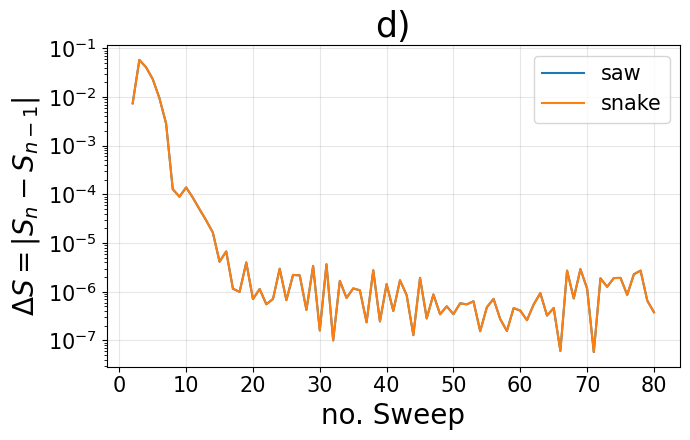

{'pila':     sweep    energy          spin  maxdim   dmrg_maxerr
 0       1 -6.893343  1.420477e-01      50  1.604514e-04
 1       2 -6.950219  1.346415e-01     100  3.829667e-05
 2       3 -6.994782  7.701346e-02     150  3.864498e-05
 3       4 -7.025241  3.623611e-02     200  1.921059e-05
 4       5 -7.042362  1.291293e-02     300  4.213852e-06
 ..    ...       ...           ...     ...           ...
 75     76 -7.054696  9.886937e-07    1056  4.044972e-08
 76     77 -7.054700  3.271158e-06    1063  2.468150e-08
 77     78 -7.054702  5.511225e-07    1059  4.396549e-08
 78     79 -7.054701  1.210891e-06    1063  3.119513e-08
 79     80 -7.054683  8.318374e-07    1061  5.091547e-08
 
 [80 rows x 5 columns],
 'truesnake':     sweep    energy          spin  maxdim   dmrg_maxerr
 0       1 -6.893343  1.420477e-01      50  1.604514e-04
 1       2 -6.950219  1.346415e-01     100  3.829667e-05
 2       3 -6.994782  7.701346e-02     150  3.864498e-05
 3       4 -7.025241  3.623611e-02     20

In [27]:
# Dostępne: "energy", "spin", "maxdim", "dmrg_maxerr"
plot_dmrg_quality(
    plot_quantity="spin",
    plot_type=["pila", "truesnake"],
    logy=True,
    marker=None,
    angles="all",
    axis__label_size=20,
    axis_number_size=15,
    title="d)",
)